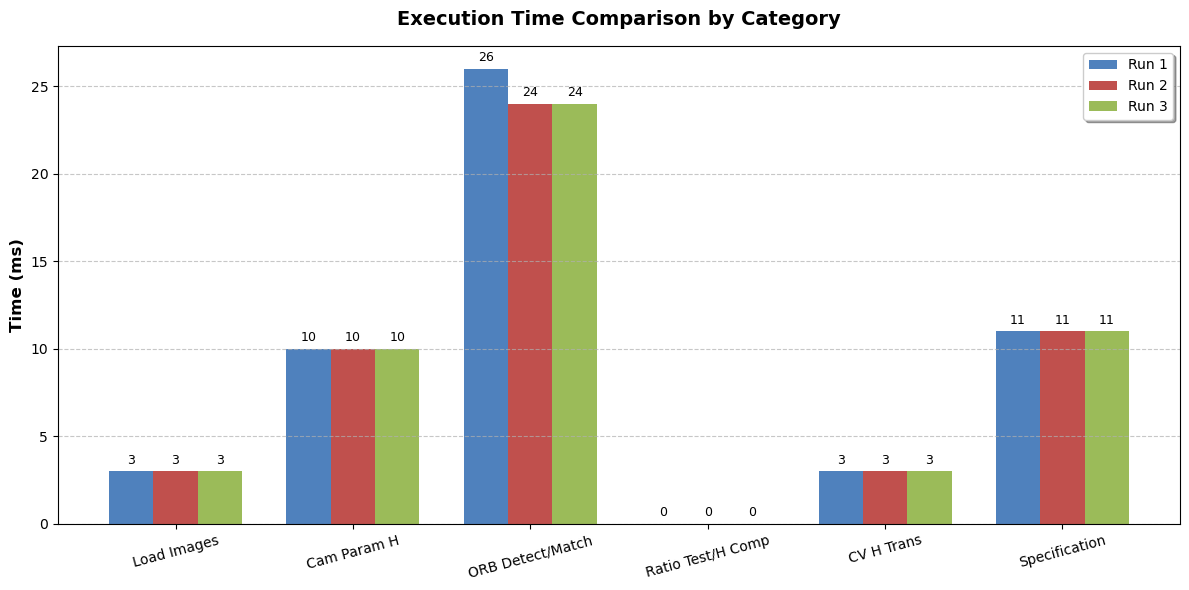

In [4]:
# %matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
categories = [
    "Load Images",
    "Cam Param H",
    "ORB Detect/Match",
    "Ratio Test/H Comp",
    "CV H Trans",
    "Specification",
]

run1 = [3, 10, 26, 0, 3, 11]
run2 = [3, 10, 24, 0, 3, 11]
run3 = [3, 10, 24, 0, 3, 11]

x = np.arange(len(categories))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

rects1 = ax.bar(x - width, run1, width, label="Run 1", color="#4f81bd")
rects2 = ax.bar(x, run2, width, label="Run 2", color="#c0504d")
rects3 = ax.bar(x + width, run3, width, label="Run 3", color="#9bbb59")

ax.set_ylabel("Time (ms)", fontsize=12, fontweight="bold")
ax.set_title(
    "Execution Time Comparison by Category", fontsize=14, fontweight="bold", pad=15
)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10, rotation=15)
ax.legend(frameon=True, shadow=True)
ax.grid(axis="y", linestyle="--", alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )


autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()


0: 448x640 1 person, 3 chairs, 2 potted plants, 1 vase, 244.9ms
Speed: 1.4ms preprocess, 244.9ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)


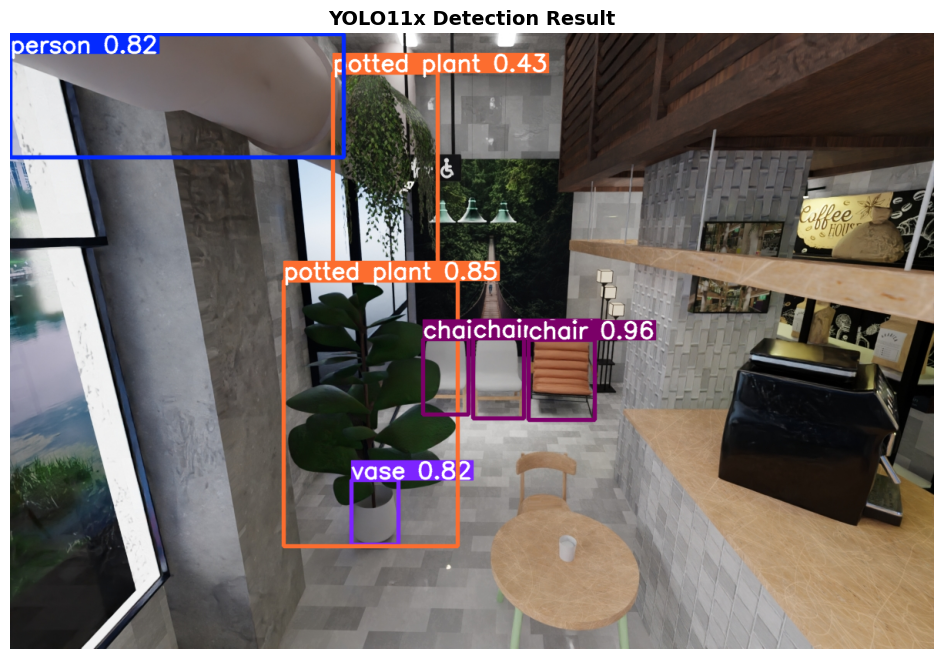

In [5]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO("yolo11x.pt")
image_path = "input/first.bmp"
bgr_img = cv2.imread(image_path)

if bgr_img is None:
    print(f"Error: {image_path}")
else:
    results = model(bgr_img, conf=0.25)
    annotated_frame = results[0].plot()
    rgb_img = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8), dpi=100)
    plt.imshow(rgb_img)
    plt.axis("off")
    plt.title("YOLO11x Detection Result", fontsize=14, fontweight="bold")
    plt.show()

=== 데이터 파싱 완료 (상위 5개 항목) ===
    header                            operation    us     ms  \
0    bmpio   Loading BMP file : input/first.bmp   915  0.915   
1    bmpio  Loading BMP file : input/second.bmp   852  0.852   
2  masking                      loadcord method   110  0.110   
3  masking                  makeQuadMask method  1174  1.174   
4  masking                       masking method  2771  2.771   

                                      full_op  
0   bmpio: Loading BMP file : input/first.bmp  
1  bmpio: Loading BMP file : input/second.bmp  
2                    masking: loadcord method  
3                masking: makeQuadMask method  
4                     masking: masking method  


📊 [1] 연산 시간 요약
• 전체 총 연산 시간 (bmpio 포함) : 140,140 us (140.140 ms)
• bmpio 제외 총 연산 시간        : 76,565 us (76.565 ms)
• I/O(bmpio) 지중 비중          : 45.37%




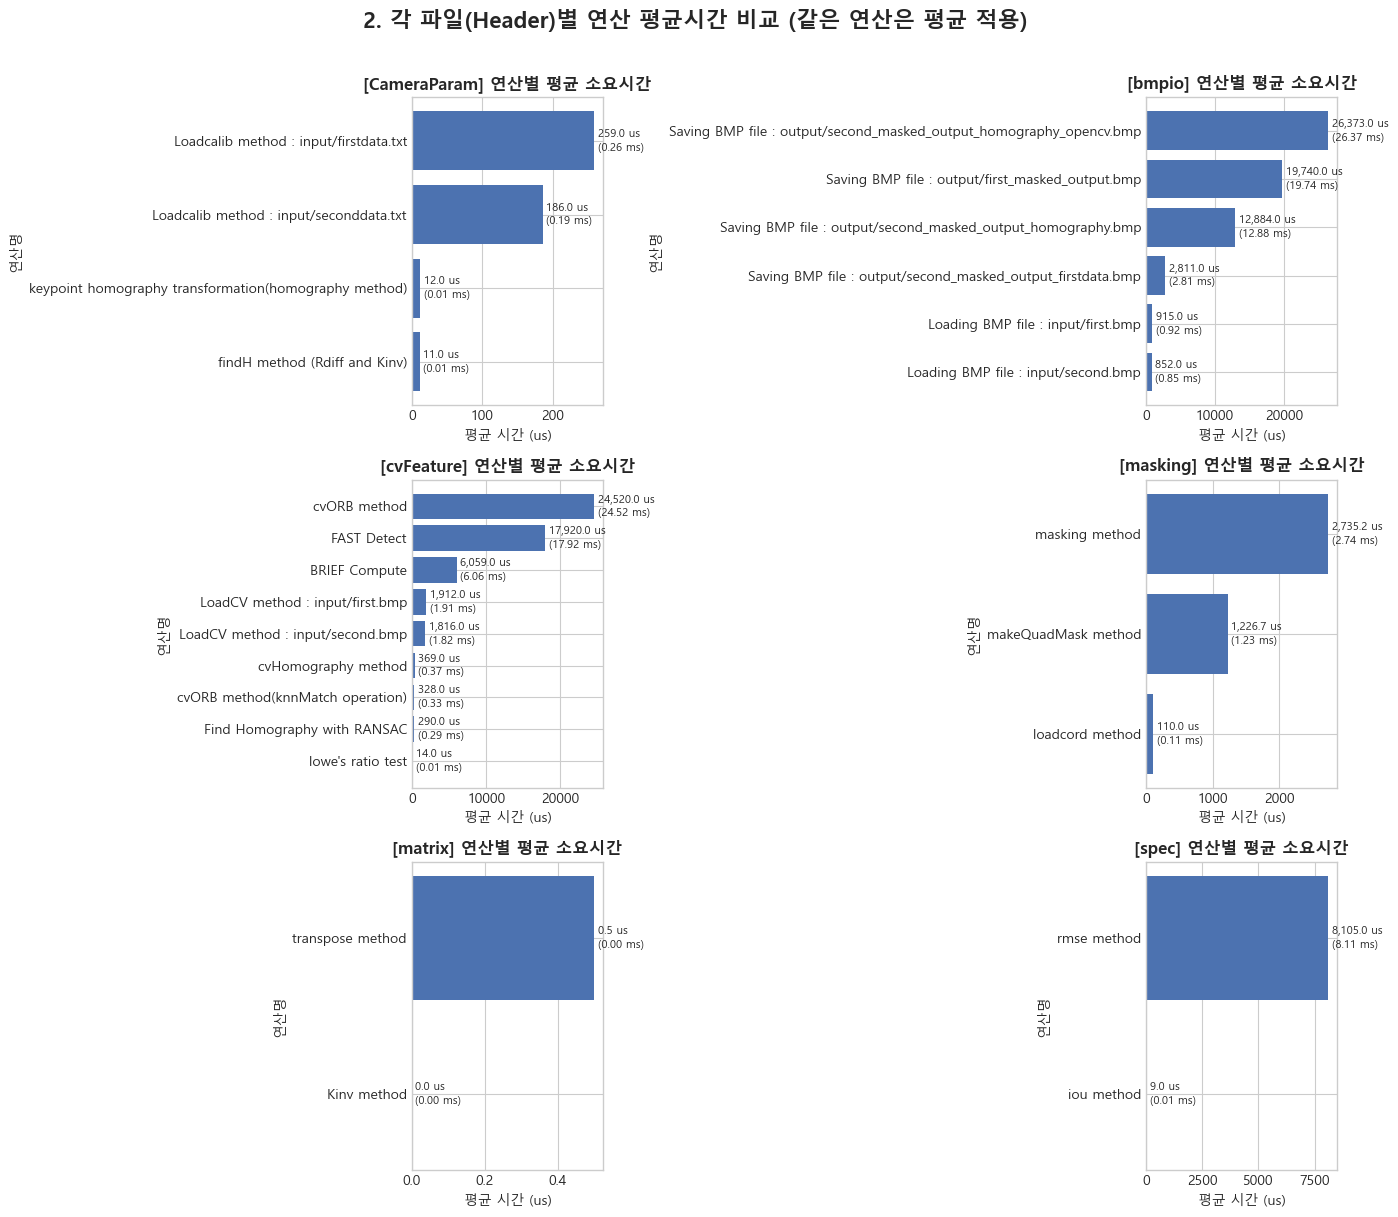

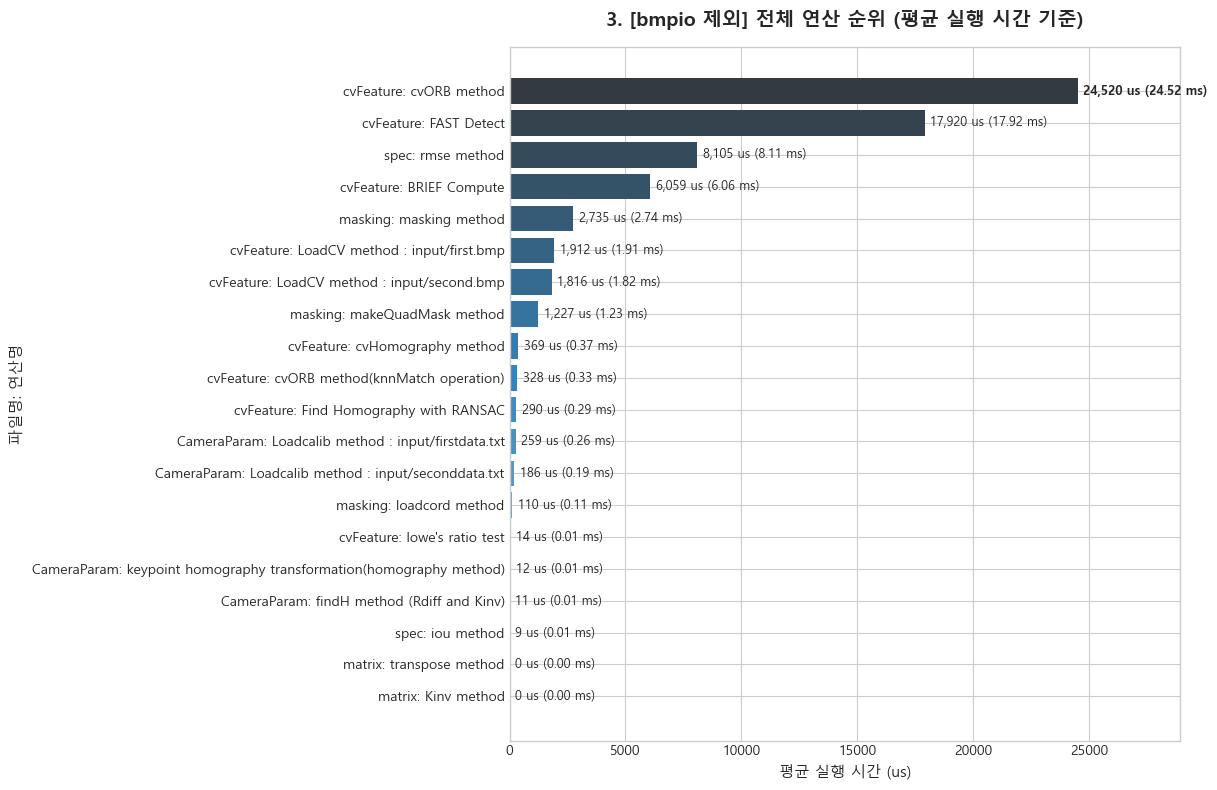

In [1]:
# %% [1] 라이브러리 임포트 및 한글 폰트 설정
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 그래프 스타일 및 한글 폰트 설정 (Windows/Linux/Mac 지원)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.family"] = "Malgun Gothic" if os.name == "nt" else "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# %% [2] 데이터 로드 및 전처리
FILE_PATH = "output/timelog.txt"

# txt 파일 읽기 (컬럼: header, operation, us)
df = pd.read_csv(
    FILE_PATH,
    header=None,
    names=["header", "operation", "us"],
    skipinitialspace=True,
)

# 데이터 타입 정리 및 ms 단위 컬럼 추가
df["header"] = df["header"].str.strip()
df["operation"] = df["operation"].str.strip()
df["us"] = pd.to_numeric(df["us"], errors="coerce")
df["ms"] = df["us"] / 1000.0  # 마이크로초 -> 밀리초 변환

# 전체 항목 간략명 (파일명/연산명)
df["full_op"] = df["header"] + ": " + df["operation"]

print("=== 데이터 파싱 완료 (상위 5개 항목) ===")
print(df.head())
print("\n" + "=" * 50 + "\n")

# %% [3] 1. bmpio를 뺀 전체 연산 시간 계산
df_no_bmpio = df[df["header"] != "bmpio"]

total_us_all = df["us"].sum()
total_us_no_bmpio = df_no_bmpio["us"].sum()

print("📊 [1] 연산 시간 요약")
print(
    f"• 전체 총 연산 시간 (bmpio 포함) : {total_us_all:,} us ({total_us_all / 1000:.3f} ms)"
)
print(
    f"• bmpio 제외 총 연산 시간        : {total_us_no_bmpio:,} us ({total_us_no_bmpio / 1000:.3f} ms)"
)
print(
    f"• I/O(bmpio) 지중 비중          : {(total_us_all - total_us_no_bmpio) / total_us_all * 100:.2f}%"
)
print("\n" + "=" * 50 + "\n")

# %% [4] 2. 각 파일(모듈)별 연산시간 비교 그래프 (동일 연산명 평균값 기준)
# 각 파일(header) 및 연산(operation)별 평균값 산출
df_avg = (
    df.groupby(["header", "operation"], as_index=False)["us"]
    .mean()
    .rename(columns={"us": "avg_us"})
)
df_avg["avg_ms"] = df_avg["avg_us"] / 1000.0

# 모듈 목록 추출
headers = df_avg["header"].unique()

# 서브플롯 개수 및 배치 설정 (2열로 배치)
num_headers = len(headers)
cols = 2
rows = (num_headers + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), squeeze=False)
axes = axes.flatten()

# 각 파일별 막대그래프 그리기
for idx, header_name in enumerate(headers):
    ax = axes[idx]
    sub_df = (
        df_avg[df_avg["header"] == header_name]
        .sort_values(by="avg_us", ascending=True)
    )

    bars = ax.barh(sub_df["operation"], sub_df["avg_us"], color="#4C72B0")
    ax.set_title(f"[{header_name}] 연산별 평균 소요시간", fontsize=12, fontweight="bold")
    ax.set_xlabel("평균 시간 (us)")
    ax.set_ylabel("연산명")

    # 막대 옆에 숫자 표기
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + (max(sub_df["avg_us"]) * 0.02),
            bar.get_y() + bar.get_height() / 2,
            f"{width:,.1f} us\n({width/1000:.2f} ms)",
            va="center",
            fontsize=8,
        )

# 남는 빈 그래프 영역 비활성화
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "2. 각 파일(Header)별 연산 평균시간 비교 (같은 연산은 평균 적용)",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

# %% [5] 3. bmpio를 뺀 전체 파일명/연산명 순위 그래프
# bmpio 제외 항목들에 대한 (파일명/연산명) 평균 계산 및 내림차순 정렬
df_rank = (
    df_no_bmpio.groupby("full_op", as_index=False)["us"]
    .mean()
    .sort_values(by="us", ascending=True)
)
df_rank["ms"] = df_rank["us"] / 1000.0

plt.figure(figsize=(12, max(6, len(df_rank) * 0.4)))

# 팔레트 설정으로 상위 병목 지점 강조
colors = sns.color_palette("Blues_d", n_colors=len(df_rank))

bars = plt.barh(df_rank["full_op"], df_rank["us"], color=colors)
plt.title(
    "3. [bmpio 제외] 전체 연산 순위 (평균 실행 시간 기준)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("평균 실행 시간 (us)", fontsize=11)
plt.ylabel("파일명: 연산명", fontsize=11)

# 데이터 라벨 표기 (마이크로초 및 밀리초)
max_val = df_rank["us"].max()
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (max_val * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f} us ({width/1000:.2f} ms)",
        va="center",
        fontsize=9,
        fontweight="bold" if width == max_val else "normal",
    )

plt.xlim(0, max_val * 1.18)  # 라벨 텍스트 잘림 방지 margin
plt.tight_layout()
plt.show()